In [4]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown, Image
from google.colab import files

# Folder where all submission files will be saved
os.makedirs("RAB_Task_02_Submission", exist_ok=True)

# Change this only if you want a different example service name
SERVICE_NAME = "Student Task Management API"
REGION = "AWS us-east-1"
HOURS_PER_MONTH = 730
DAYS_PER_MONTH = 30

print("Setup complete.")
print("Service:", SERVICE_NAME)
print("Region used for estimates:", REGION)

Setup complete.
Service: Student Task Management API
Region used for estimates: AWS us-east-1


# RAB Tech Academy Internship – Task 02

## Service Blueprint, SLOs & Cloud Cost Envelope

**Example service:** Student Task Management API  
**Architecture:** Two-tier web service  
**Cloud provider used for the estimate:** AWS  
**Region:** us-east-1  

### Purpose

This notebook designs the operational contract for a small web service before infrastructure and deployment automation are selected.

It includes:

1. Service blueprint
2. Availability and latency SLIs/SLOs
3. Error budgets and paging thresholds
4. Three cloud-cost scenarios
5. Architecture Decision Records

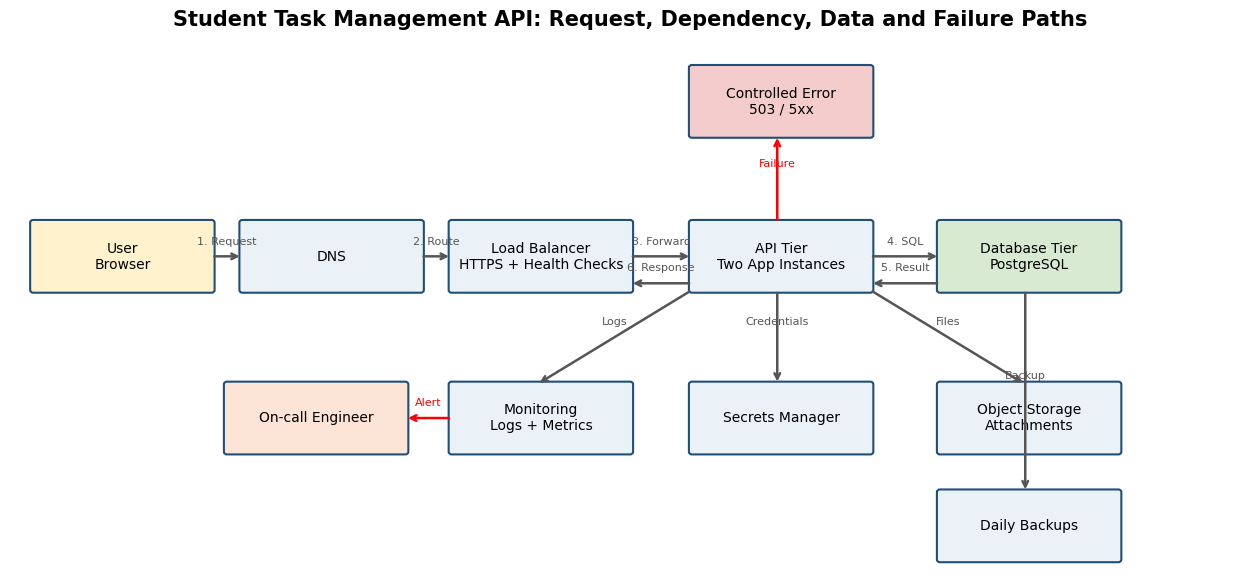

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")

def add_box(x, y, text, color="#EAF2F8"):
    box = FancyBboxPatch(
        (x, y), 2.3, 1.0,
        boxstyle="round,pad=0.04",
        edgecolor="#1F4E79",
        facecolor=color,
        linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(
        x + 1.15, y + 0.5, text,
        ha="center", va="center",
        fontsize=10, wrap=True
    )

def add_arrow(x1, y1, x2, y2, label="", color="#555555"):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.8)
    )
    if label:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.18,
            label,
            ha="center",
            fontsize=8,
            color=color
        )

# Main request path
add_box(0.3, 4.2, "User\nBrowser", "#FFF2CC")
add_box(3.0, 4.2, "DNS")
add_box(5.7, 4.2, "Load Balancer\nHTTPS + Health Checks")
add_box(8.8, 4.2, "API Tier\nTwo App Instances")
add_box(12.0, 4.2, "Database Tier\nPostgreSQL", "#D9EAD3")

# Supporting services
add_box(8.8, 1.8, "Secrets Manager")
add_box(12.0, 1.8, "Object Storage\nAttachments")
add_box(5.7, 1.8, "Monitoring\nLogs + Metrics")
add_box(12.0, 0.2, "Daily Backups")
add_box(2.8, 1.8, "On-call Engineer", "#FCE4D6")
add_box(8.8, 6.5, "Controlled Error\n503 / 5xx", "#F4CCCC")

# Request arrows
add_arrow(2.6, 4.7, 3.0, 4.7, "1. Request")
add_arrow(5.3, 4.7, 5.7, 4.7, "2. Route")
add_arrow(8.0, 4.7, 8.8, 4.7, "3. Forward")
add_arrow(11.1, 4.7, 12.0, 4.7, "4. SQL")
add_arrow(12.0, 4.3, 11.1, 4.3, "5. Result")
add_arrow(8.8, 4.3, 8.0, 4.3, "6. Response")

# Dependency arrows
add_arrow(9.9, 4.2, 9.9, 2.8, "Credentials")
add_arrow(11.1, 4.2, 13.1, 2.8, "Files")
add_arrow(8.8, 4.2, 6.8, 2.8, "Logs")
add_arrow(13.1, 4.2, 13.1, 1.2, "Backup")

# Failure and alert arrows
add_arrow(9.9, 5.2, 9.9, 6.5, "Failure", "red")
add_arrow(5.7, 2.3, 5.1, 2.3, "Alert", "red")

plt.title(
    f"{SERVICE_NAME}: Request, Dependency, Data and Failure Paths",
    fontsize=15,
    fontweight="bold"
)

plt.savefig(
    "RAB_Task_02_Submission/service_blueprint.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Operational Paths

### Request path
A user sends an HTTPS request through a browser. DNS routes the request to the load balancer. The load balancer sends the request to a healthy API instance. The API reads or updates task data in PostgreSQL and returns a JSON response.

### Dependency path
The API uses Secrets Manager for database credentials, object storage for attachments, and monitoring for logs, metrics, and alerts.

### Deployment path
Source code is tested through CI/CD, packaged as a container, and deployed using a rolling deployment. Two API instances are used in production so that one instance can remain available if the other fails or is being updated.

### Data path
Task data is stored in PostgreSQL. User attachments are stored in object storage. Logs are retained for 30 days. Database backups are retained for seven days.

### Failure path
If an API instance fails, the load balancer sends traffic to the remaining healthy instance. If the database is unavailable, the API returns a controlled 503 response. Monitoring records the error and pages the on-call engineer if the agreed threshold is exceeded.

In [6]:
availability_target = 99.9

allowed_downtime_minutes = (
    DAYS_PER_MONTH * 24 * 60 * (1 - availability_target / 100)
)

slo_workbook = pd.DataFrame([
    {
        "SLI": "Availability",
        "How it is measured": "Successful valid requests / total valid requests",
        "SLO target": "99.90% availability per 30-day month",
        "Error budget": f"{allowed_downtime_minutes:.1f} minutes downtime per month",
        "Warning threshold": "Availability below 99.95% for 1 hour",
        "Paging threshold": "Availability below 99.80% for 15 minutes"
    },
    {
        "SLI": "Latency",
        "How it is measured": "95th percentile API response time",
        "SLO target": "p95 response time must be 300 ms or less",
        "Error budget": "Up to 5% of requests may exceed 300 ms",
        "Warning threshold": "p95 above 250 ms for 15 minutes",
        "Paging threshold": "p95 above 500 ms for 10 minutes"
    },
    {
        "SLI": "Server error rate",
        "How it is measured": "HTTP 5xx responses / total requests",
        "SLO target": "Less than 0.10% 5xx errors per month",
        "Error budget": "0.10% of requests may fail",
        "Warning threshold": "5xx above 0.50% for 10 minutes",
        "Paging threshold": "5xx above 2.00% for 5 minutes"
    },
    {
        "SLI": "Database backup success",
        "How it is measured": "Successful backups / scheduled backups",
        "SLO target": "100% successful daily backup",
        "Error budget": "No missed daily backup",
        "Warning threshold": "Backup delayed by more than 2 hours",
        "Paging threshold": "Backup fails or is missed"
    }
])

display(Markdown("## SLO Workbook"))
display(slo_workbook)

slo_workbook.to_csv(
    "RAB_Task_02_Submission/slo_workbook.csv",
    index=False
)

print(
    f"For a 99.9% availability target, the service can be unavailable for "
    f"{allowed_downtime_minutes:.1f} minutes in a 30-day month."
)

## SLO Workbook

,SLI,How it is measured,SLO target,Error budget,Warning threshold,Paging threshold
0,Availability,Successful valid requests / total valid requests,99.90% availability per 30-day month,43.2 minutes downtime per month,Availability below 99.95% for 1 hour,Availability below 99.80% for 15 minutes
1,Latency,95th percentile API response time,p95 response time must be 300 ms or less,Up to 5% of requests may exceed 300 ms,p95 above 250 ms for 15 minutes,p95 above 500 ms for 10 minutes
2,Server error rate,HTTP 5xx responses / total requests,Less than 0.10% 5xx errors per month,0.10% of requests may fail,5xx above 0.50% for 10 minutes,5xx above 2.00% for 5 minutes
3,Database backup success,Successful backups / scheduled backups,100% successful daily backup,No missed daily backup,Backup delayed by more than 2 hours,Backup fails or is missed


For a 99.9% availability target, the service can be unavailable for 43.2 minutes in a 30-day month.


In [7]:
# Approximate pricing assumptions in USD.
# These are planning estimates only, excluding tax.
# Update them if your trainer gives you a specific cloud provider/region.

PRICE = {
    "api_instance_hour": 0.0208,
    "database_hour": 0.0170,
    "block_storage_gb": 0.08,
    "object_storage_gb": 0.023,
    "data_transfer_gb": 0.09,
    "logging_gb": 0.50,
    "backup_gb": 0.05,
    "support_monthly": 0.00
}

traffic_scenarios = pd.DataFrame([
    {
        "Scenario": "Low Traffic",
        "Requests per Month": 100000,
        "API Instances": 1,
        "Database Instances": 1,
        "Block Storage GB": 30,
        "Object Storage GB": 10,
        "Data Transfer GB": 10,
        "Logging GB": 2,
        "Backup GB": 20,
        "Support Plan": "Basic"
    },
    {
        "Scenario": "Medium Traffic",
        "Requests per Month": 1000000,
        "API Instances": 2,
        "Database Instances": 1,
        "Block Storage GB": 80,
        "Object Storage GB": 100,
        "Data Transfer GB": 100,
        "Logging GB": 25,
        "Backup GB": 100,
        "Support Plan": "Basic"
    },
    {
        "Scenario": "High Traffic",
        "Requests per Month": 10000000,
        "API Instances": 4,
        "Database Instances": 2,
        "Block Storage GB": 250,
        "Object Storage GB": 500,
        "Data Transfer GB": 1000,
        "Logging GB": 150,
        "Backup GB": 500,
        "Support Plan": "Basic"
    }
])

def calculate_monthly_cost(row):
    compute = row["API Instances"] * HOURS_PER_MONTH * PRICE["api_instance_hour"]
    database = row["Database Instances"] * HOURS_PER_MONTH * PRICE["database_hour"]
    block_storage = row["Block Storage GB"] * PRICE["block_storage_gb"]
    object_storage = row["Object Storage GB"] * PRICE["object_storage_gb"]
    transfer = row["Data Transfer GB"] * PRICE["data_transfer_gb"]
    logging = row["Logging GB"] * PRICE["logging_gb"]
    backup = row["Backup GB"] * PRICE["backup_gb"]
    support = PRICE["support_monthly"]

    return pd.Series({
        "Compute ($)": compute,
        "Database ($)": database,
        "Block Storage ($)": block_storage,
        "Object Storage ($)": object_storage,
        "Data Transfer ($)": transfer,
        "Logging ($)": logging,
        "Backup ($)": backup,
        "Support ($)": support,
        "Total Monthly Cost ($)": (
            compute + database + block_storage +
            object_storage + transfer + logging +
            backup + support
        )
    })

cost_values = traffic_scenarios.apply(calculate_monthly_cost, axis=1)

cost_model = pd.concat([traffic_scenarios, cost_values], axis=1)

cost_columns = [
    "Compute ($)", "Database ($)", "Block Storage ($)",
    "Object Storage ($)", "Data Transfer ($)", "Logging ($)",
    "Backup ($)", "Support ($)", "Total Monthly Cost ($)"
]

cost_model[cost_columns] = cost_model[cost_columns].round(2)

display(Markdown("## Three-Scenario Monthly Cost Model"))
display(cost_model)

cost_model.to_csv(
    "RAB_Task_02_Submission/three_scenario_cost_model.csv",
    index=False
)

## Three-Scenario Monthly Cost Model

,Scenario,Requests per Month,API Instances,Database Instances,Block Storage GB,Object Storage GB,Data Transfer GB,Logging GB,Backup GB,Support Plan,Compute ($),Database ($),Block Storage ($),Object Storage ($),Data Transfer ($),Logging ($),Backup ($),Support ($),Total Monthly Cost ($)
0,Low Traffic,100000,1,1,30,10,10,2,20,Basic,15.18,12.41,2.4,0.23,0.9,1.0,1.0,0.0,33.12
1,Medium Traffic,1000000,2,1,80,100,100,25,100,Basic,30.37,12.41,6.4,2.30,9.0,12.5,5.0,0.0,77.98
2,High Traffic,10000000,4,2,250,500,1000,150,500,Basic,60.74,24.82,20.0,11.50,90.0,75.0,25.0,0.0,307.06


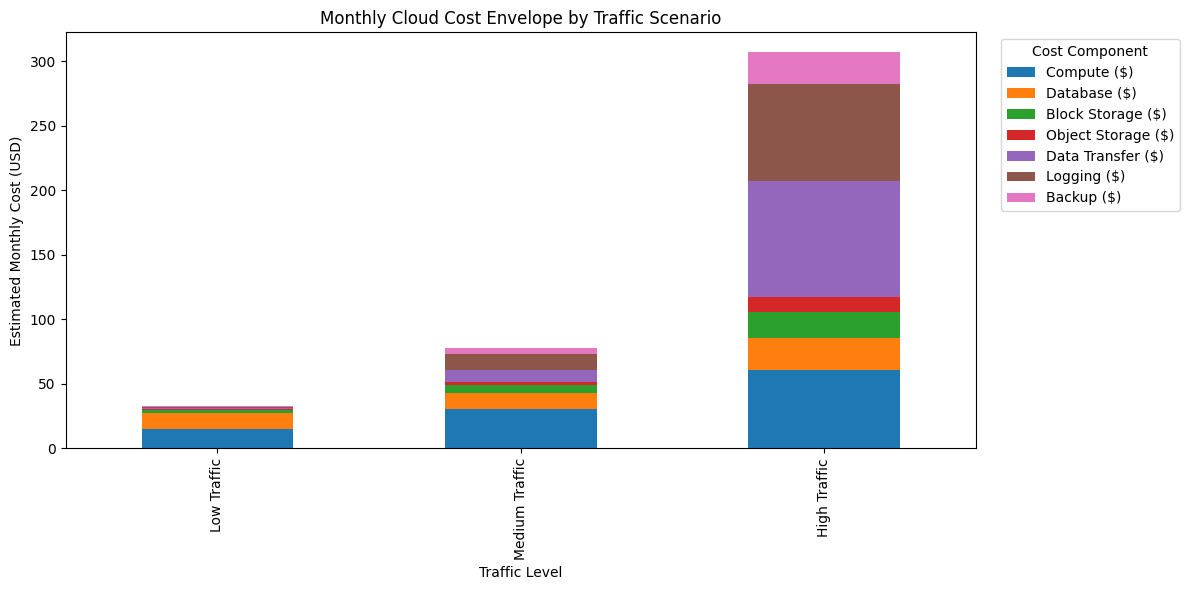

In [8]:
chart_columns = [
    "Compute ($)",
    "Database ($)",
    "Block Storage ($)",
    "Object Storage ($)",
    "Data Transfer ($)",
    "Logging ($)",
    "Backup ($)"
]

chart_data = cost_model.set_index("Scenario")[chart_columns]

chart_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Monthly Cloud Cost Envelope by Traffic Scenario")
plt.xlabel("Traffic Level")
plt.ylabel("Estimated Monthly Cost (USD)")
plt.legend(
    title="Cost Component",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "RAB_Task_02_Submission/cost_envelope_chart.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [9]:
architecture_decisions = """
# Architecture Decision Records

## ADR-001: Region Choice

**Decision:** Use AWS us-east-1 as the primary deployment region.

**Reason:** A single region is suitable for a small web service because it reduces cost and operational complexity.

**Consequence:** A major regional outage can affect the service, so backups must be available for recovery.

---

## ADR-002: Recovery Objectives

**Decision:** Set Recovery Point Objective (RPO) to 24 hours and Recovery Time Objective (RTO) to 4 hours.

**RPO:** At most 24 hours of data may be lost after a major disaster.

**RTO:** The service should be restored within four hours.

**Implementation:** Create daily database backups and document the restoration procedure.

---

## ADR-003: Secret Management

**Decision:** Store database passwords and API keys in a secrets-management service.

**Reason:** Secrets must never be stored in source code, GitHub repositories, public notebooks, or screenshots.

**Implementation:** The API retrieves secrets at runtime using its own restricted cloud role.

---

## ADR-004: Least-Privilege Access

**Decision:** Use separate cloud roles for the API, deployment pipeline, monitoring, and administrators.

**Reason:** Each identity should receive only the permissions required for its task.

**Example:** The API can read its own database secret and write application logs, but cannot change billing, create users, or access unrelated storage.

---

## ADR-005: Availability Design

**Decision:** Use a load balancer and two API instances for medium and high traffic.

**Reason:** One API server is a single point of failure.

**Consequence:** If one API instance fails, traffic is sent to the healthy instance.
"""

with open(
    "RAB_Task_02_Submission/architecture_decision_records.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(architecture_decisions)

display(Markdown(architecture_decisions))


# Architecture Decision Records

## ADR-001: Region Choice

**Decision:** Use AWS us-east-1 as the primary deployment region.

**Reason:** A single region is suitable for a small web service because it reduces cost and operational complexity.

**Consequence:** A major regional outage can affect the service, so backups must be available for recovery.

---

## ADR-002: Recovery Objectives

**Decision:** Set Recovery Point Objective (RPO) to 24 hours and Recovery Time Objective (RTO) to 4 hours.

**RPO:** At most 24 hours of data may be lost after a major disaster.

**RTO:** The service should be restored within four hours.

**Implementation:** Create daily database backups and document the restoration procedure.

---

## ADR-003: Secret Management

**Decision:** Store database passwords and API keys in a secrets-management service.

**Reason:** Secrets must never be stored in source code, GitHub repositories, public notebooks, or screenshots.

**Implementation:** The API retrieves secrets at runtime using its own restricted cloud role.

---

## ADR-004: Least-Privilege Access

**Decision:** Use separate cloud roles for the API, deployment pipeline, monitoring, and administrators.

**Reason:** Each identity should receive only the permissions required for its task.

**Example:** The API can read its own database secret and write application logs, but cannot change billing, create users, or access unrelated storage.

---

## ADR-005: Availability Design

**Decision:** Use a load balancer and two API instances for medium and high traffic.

**Reason:** One API server is a single point of failure.

**Consequence:** If one API instance fails, traffic is sent to the healthy instance.


In [10]:
shutil.make_archive(
    "RAB_Tech_Academy_Task_02_Submission",
    "zip",
    "RAB_Task_02_Submission"
)

files.download("RAB_Tech_Academy_Task_02_Submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>